In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from crpropa import *

# from UHECR_statistics import *

In [2]:
def read_crpropa_textfile(filename, chunksize=1e4, **kwds):
    """Reads a textfile produced with crpropa by chunks 
    of size set by chunksize
    """
    with open(filename, 'r') as f:
        header = f.readline()
    colnames = header.strip('#\t').strip('\n').split('\t')

    for chunk in pd.read_csv(filename, header=0, comment='#', chunksize=chunksize, sep='\t', names=colnames, **kwds):
        df = chunk
        break

    return df

In [6]:
from core import *

data_files = {
    'path' : os.path.abspath('/home/leonel/GitProjects/CRPropa3/data-2021-07-30/data/'),
    
    'photodisintegration': {
        'rates_cmb' : 'Photodisintegration/rate_CMB.txt',
        'branchings_cmb' : 'Photodisintegration/branching_CMB.txt',
        'rates_ebl' : 'Photodisintegration/rate_IRB_Gilmore12.txt',
        'branchings_ebl' : 'Photodisintegration/branching_IRB_Gilmore12.txt',
    },
}

ic1 = InteractionCore_CRPropA_pdis(data_files)

No suitable isomer found for remnant ( 1,  1)
No suitable isomer found for remnant ( 1,  1)


No suitable isomer found for remnant ( 1,  1)
No suitable isomer found for remnant ( 1,  1)




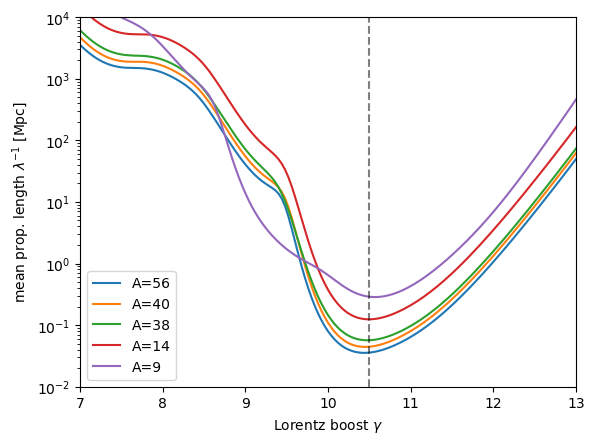

In [7]:
lgs = np.linspace(7, 13, 21)

for (A, Z) in [(56, 26), (40, 20), (38, 19), (14, 7), (9, 4)]:
    idx_spec = ic1.species.index((Z, A))
    plt.semilogy(np.log10(ic1.boosts), 1/-ic1.tensor[idx_spec, idx_spec, :], label=f'A={A}')

plt.axvline(10.5, ls='--', alpha=.5, c='k')
plt.xlabel('Lorentz boost $\gamma$')
plt.ylabel('mean prop. length $\lambda^{-1}$ [Mpc]')
plt.xlim(7, 13)
plt.ylim(1e-2, 1e4)
plt.legend()